# Ajuste de XGBoost

A lo largo de los siguientes ejercicios, aprenderás a usar Python para construir e interpretar un modelo de clasificación XGBoost usando la biblioteca de modelado XGBoost. Antes de comenzar con este ejercicio de programación, recomendamos encarecidamente ver la conferencia en video y completar la IVQ para los temas asociados.


Todo la información que necesitas para resolver esta tarea está en este cuaderno, y todo el código que implementarás tendrá lugar dentro de este cuaderno.


Temas de enfoque incluyen:

* Declaraciones de importación relevantes
* Ajuste de un modelo
* Uso de `GridSearchCV` para validar el modelo mediante validación cruzada y ajustar los siguientes hiperparámetros:
  - `max_depth`  
  - `min_child_weight`  
  - `learning_rate`  
  - `n_estimators`  
* Evaluación del modelo usando precisión, recall y puntuación F1
* Examen de la importancia de las características


A medida que avanzamos, puedes encontrar instrucciones sobre cómo instalar las bibliotecas requeridas a medida que surjan en este cuaderno.


## Revisión

Este cuaderno es una continuación del proyecto de rotación de bancos. A continuación se presenta un resumen de las consideraciones y decisiones que ya hemos tomado. Para una discusión detallada de estos temas, consulte el [cuaderno completamente anotado para el modelo de árbol de decisión](https://www.coursera.org/learn/the-nuts-and-bolts-of-machine-learning/ungradedLab/HVyMU/annotated-follow-along-guide-build-a-decision-tree).

>  **Objetivo del modelado:** Predecir si un cliente abandonará&mdash;una tarea de clasificación binaria

>  **Variable objetivo:** columna `Exited`&mdash;0 o 1

>  **Equilibrio de clases:** Los datos están desequilibrados 80/20 (no abandonó/abandonó), pero no realizaremos balanceo de clases.

>  **Métrica de evaluación principal:** Puntuación F1

>  **Flujo de trabajo de modelado y selección de modelos:** El modelo campeón será el modelo con la mejor puntuación F1 de validación. Solo se usará el modelo campeón para predecir en los datos de prueba. Consulte la [sección de compromisos del modelado](#trade-offs) para detalles y limitaciones de este enfoque.


## Declaraciones de importación

Antes de comenzar con los ejercicios y analizar los datos, necesitamos importar todas las bibliotecas y extensiones requeridas para este ejercicio de programación. A lo largo del curso, utilizaremos numpy y pandas para operaciones, y matplotlib para graficar.


In [1]:
import numpy as np
import pandas as pd

# This is the classifier
from xgboost import XGBClassifier

# This is the function that helps plot feature importance 
from xgboost import plot_importance

from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score,\
f1_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay

import matplotlib.pyplot as plt

# This displays all of the columns, preventing Juptyer from redacting them.
pd.set_option('display.max_columns', None)

# This module lets us save our models once we fit them.
import pickle

## Leer los datos


In [2]:
# Read in data
file = 'Churn_Modelling.csv'
df_original = pd.read_csv(file)
df_original.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Ingeniería de características


### Selección de características

En este paso, prepararemos los datos para el modelado.  Observe que hay varias columnas que no esperaríamos que ofrezcan ninguna señal predictiva al modelo. Estas columnas incluyen `RowNumber`, `CustomerID`, y `Surname`. Eliminaremos estas columnas para que no introduzcan ruido a nuestro modelo.  

También eliminaremos la columna `Gender`, porque no queremos que nuestro modelo haga predicciones basadas en el género.


In [3]:
# Drop useless and sensitive (Gender) cols
churn_df = df_original.drop(['RowNumber', 'CustomerId', 'Surname', 'Gender'], 
                            axis=1)
churn_df.head()

,CreditScore,Geography,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,41,1,83807.86,1,0,1,112542.58,0
2,502,France,42,8,159660.80,3,1,0,113931.57,1
3,699,France,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,43,2,125510.82,1,1,1,79084.10,0


### Transformación de características

A continuación, codificaremos en variables ficticias la variable `Geography`, que es categórica. Hacemos esto con la función `pd.get_dummies()` y estableciendo `drop_first='True'`, lo que reemplaza la columna `Geography` con dos nuevas columnas Boolean llamadas `Geography_Germany` y `Geography_Spain`.


In [4]:
# Dummy encode categoricals
churn_df2 = pd.get_dummies(churn_df, drop_first='True')
churn_df2.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True


## Dividir los datos

Dividiremos los datos en características y variable objetivo, y en datos de entrenamiento y datos de prueba usando la función `train_test_split()`.

No olvides incluir el parámetro `stratify=y`, ya que esto asegura que la proporción de clases 80/20 de la variable objetivo se mantenga en ambos conjuntos de datos de entrenamiento y prueba después de la división.

Por último, establecemos una semilla aleatoria para que nosotros y otros podamos reproducir nuestro trabajo.


In [5]:
# Define the y (target) variable
y = churn_df2["Exited"]

# Define the X (predictor) variables
X = churn_df2.copy()
X = X.drop("Exited", axis = 1)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, 
                                                    stratify=y, random_state=42)

## Modelado


### Ajuste de hiperparámetros con validación cruzada

El proceso de validación cruzada es el mismo que fue para los modelos de árbol de decisión y bosque aleatorio. La única diferencia es que ahora estamos ajustando diferentes hiperparámetros. Los pasos se incluyen a continuación como revisión.

Para detalles sobre la validación cruzada con `GridSearchCV`, consulte de nuevo el cuaderno de árbol de decisión, o la [documentación de GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html#sklearn.model_selection.GridSearchCV) en scikit-learn.

1. Instanciar el clasificador (y establecer el `random_state`). Tenga en cuenta aquí que hemos incluido un parámetro llamado `objective` cuyo valor es `binary:logistic`. Esto significa que el modelo está realizando una tarea de clasificación binaria que produce una probabilidad logística. El objetivo sería diferente para diferentes tipos de problemas—por ejemplo, si intentara predecir más de dos clases o realizar una regresión lineal en datos continuos. Consulte la [documentación de XGBoost](https://xgboost.readthedocs.io/en/stable/parameter.html) para más información.

2. Crear un diccionario de hiperparámetros para buscar.

3. Crear un diccionario de métricas de puntuación para capturar.

4. Instanciar el objeto `GridSearchCV`. Pasar como argumentos:
  - El clasificador (`xgb`)
  - El diccionario de hiperparámetros a buscar (`cv_params`)
  - El diccionario de métricas de puntuación (`scoring`)
  - El número de pliegues de validación cruzada que desea (`cv=5`)
  - La métrica de puntuación que desea que GridSearch utilice cuando seleccione el modelo "mejor" (es decir, el modelo que funciona mejor en promedio en todos los pliegues de validación) (`refit='f1'`)

5. Ajustar los datos (`X_train`, `y_train`) al objeto `GridSearchCV` (`xgb_cv`)

Tenga en cuenta que usamos la magia `%%time` en la parte superior de la celda donde ajustamos el modelo. Esto muestra el tiempo de ejecución final de la celda.


In [8]:
xgb = XGBClassifier(objective='binary:logistic', random_state=0) 

cv_params = {'max_depth': [4,5,6,7,8], 
             'min_child_weight': [1,2,3,4,5],
             'learning_rate': [0.1, 0.2, 0.3],
             'n_estimators': [75, 100, 125]
             }    

scoring = list({'accuracy', 'precision', 'recall', 'f1'})

xgb_cv = GridSearchCV(xgb, cv_params, scoring=scoring, cv=5, refit='f1')

**Nota**: **La siguiente operación puede tardar más de 30 minutos en completarse**


In [9]:
%%time
xgb_cv.fit(X_train, y_train)

CPU times: total: 22min 12s
Wall time: 8min 38s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.1, 0.2, ...], 'max_depth': [4, 5, ...], 'min_child_weight': [1, 2, ...], 'n_estimators': [75, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['recall', 'f1', ...]"
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from

## Pickle

Vamos a serializar el modelo para no tener que volver a ajustarlo cada vez que ejecutemos este cuaderno. Recuerda, hay tres pasos:

1. Definir la ruta a la ubicación donde se guardará
2. Escribir el archivo (es decir, guardar el modelo)
3. Leer el modelo de nuevo


In [8]:
path = '/home/jovyan/work/'

In [10]:
# Pickle the model
with open('xgb_cv_model_emi.pickle', 'wb') as to_write:
    pickle.dump(xgb_cv, to_write) 

In [11]:
# Open pickled model
with open('xgb_cv_model_emi.pickle', 'rb') as to_read:
    xgb_cv = pickle.load(to_read)

No olvides volver y comentar la línea de código donde ajustaste el modelo y el código que escribe el pickle!


Vamos a verificar la puntuación de nuestro modelo y compararla con la puntuación de nuestro bosque aleatorio en los mismos datos de entrenamiento validados cruzadamente. Tendremos que importar el modelo de bosque aleatorio guardado en pickle. ¡Aquí es donde la serialización con pickle resulta útil!


In [14]:
# Open pickled random forest model
with open('rf_cv_model.pickle', 'rb') as to_read:
    rf_cv = pickle.load(to_read)
    
# rf_cv.fit(X_train, y_train)

# print('F1 score random forest CV: ', rf_cv.best_score_)
print('F1 score XGB CV: ', xgb_cv.best_score_)

F1 score XGB CV:  0.5849358400422935


Usaremos la misma función auxiliar que usamos en notebooks anteriores para organizar nuestros resultados en un dataframe.


In [15]:
def make_results(model_name, model_object):
    '''
    Accepts as arguments a model name (your choice - string) and
    a fit GridSearchCV model object.
  
    Returns a pandas df with the F1, recall, precision, and accuracy scores
    for the model with the best mean F1 score across all validation folds.  
    '''

    # Get all the results from the CV and put them in a df
    cv_results = pd.DataFrame(model_object.cv_results_)

    # Isolate the row of the df with the max(mean f1 score)
    best_estimator_results = cv_results.iloc[cv_results['mean_test_f1'].idxmax(), :]

    # Extract accuracy, precision, recall, and f1 score from that row
    f1 = best_estimator_results.mean_test_f1
    recall = best_estimator_results.mean_test_recall
    precision = best_estimator_results.mean_test_precision
    accuracy = best_estimator_results.mean_test_accuracy
  
    # Create table of results
    table = pd.DataFrame({'Model': [model_name],
                          'F1': [f1],
                          'Recall': [recall],
                          'Precision': [precision],
                          'Accuracy': [accuracy]
                         }
                        )
  
    return table

In [16]:
# Create xgb model results table
xgb_cv_results = make_results('XGBoost CV', xgb_cv)
xgb_cv_results

,Model,F1,Recall,Precision,Accuracy
0,XGBoost CV,0.584936,0.483641,0.742712,0.8604


Ahora leeremos de nuevo la tabla de resultados maestra del último cuaderno y la concatenaremos con los resultados que acabamos de crear arriba.


In [18]:
# Read in master results table
results = pd.read_csv('results2.csv')

# Concatentate xgb model results table with master results table
results = pd.concat([xgb_cv_results, results]).sort_values(by=['F1'], 
                                                           ascending=False)
results

,Model,F1,Recall,Precision,Accuracy
0,XGBoost CV,0.584936,0.483641,0.742712,0.860400
1,Random Forest CV,0.580529,0.472517,0.756289,0.861333
0,Random Forest Validated,0.575510,0.460784,0.766304,0.861333
2,Tuned Decision Tree,0.560655,0.469255,0.701608,0.850400


## Selección de modelo y resultados finales


### Prediciendo en los datos de prueba

¡Estamos listos para seleccionar un modelo campeón! Basándonos en la tabla anterior, es claro que nuestro modelo XGBoost tiene la puntuación F1 más alta en los datos de validación por un pequeño margen.

Dado que no construiremos más modelos, finalmente podemos usar nuestro modelo campeón (XGBoost) para predecir en los datos de prueba.


In [19]:
# Predict on test data
xgb_cv_preds = xgb_cv.predict(X_test)
print('F1 score final XGB model: ', f1_score(y_test, xgb_cv_preds))
print('Recall score final XGB model: ', recall_score(y_test, xgb_cv_preds))
print('Precision score final XGB model: ', precision_score(y_test, xgb_cv_preds))
print('Accuracy score final XGB model: ', accuracy_score(y_test, xgb_cv_preds))

F1 score final XGB model:  0.611957796014068
Recall score final XGB model:  0.5127701375245579
Precision score final XGB model:  0.7587209302325582
Accuracy score final XGB model:  0.8676


¡Vaya! El modelo final funcionó incluso mejor en los datos de prueba que en los datos de validación. Esto es inusual. Por lo general, el rendimiento en los datos de prueba es un poco peor que en los datos de validación. Pero la diferencia aquí es pequeña, así que no es motivo de preocupación.

Vamos a revisar nuestra matriz de confusión.


### Matriz de confusión


In [20]:
# Create helper function to plot confusion matrix
def conf_matrix_plot(model, x_data, y_data):
    '''
    Accepts as argument model object, X data (test or validate), and y data (test or validate). 
    Returns a plot of confusion matrix for predictions on y data.
    ''' 
    model_pred = model.predict(x_data)
    cm = confusion_matrix(y_data, model_pred, labels=model.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                             display_labels=model.classes_)
  
    disp.plot()
    plt.show()

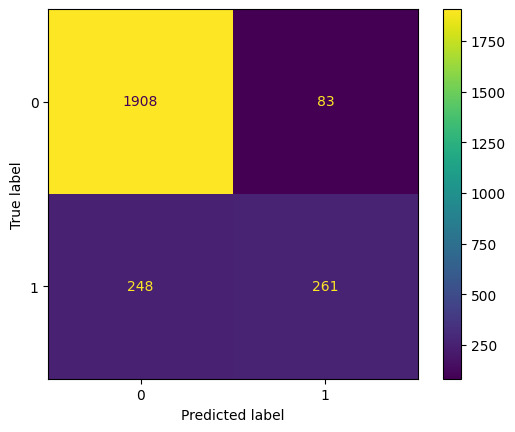

In [21]:
conf_matrix_plot(xgb_cv, X_test, y_test)

De las 2,500 personas en nuestros datos de prueba, hay 509 clientes que dejaron el banco. De esos, nuestro modelo captura 256. La matriz de confusión indica que, cuando el modelo comete un error, generalmente es un error de Tipo II&mdash;da un falso negativo al no predecir que un cliente se irá. Por otro lado, comete mucho menos errores de Tipo I, que son falsos positivos.

En última instancia, si estos resultados son aceptables depende de los costos de las medidas tomadas para evitar que un cliente se vaya versus el valor de retenerlo. En este caso, los líderes del banco pueden decidir que preferirían tener más verdaderos positivos, incluso si eso significa capturar también significativamente más falsos positivos. Si ese es el caso, quizás optimizar los modelos basándose en sus puntuaciones F1 no sea suficiente. Tal vez priorizaríamos una métrica de evaluación diferente.

Una forma de modificar la toma de decisiones sin volver a entrenar el modelo es ajustar el umbral en el que el modelo predice una respuesta positiva. En otras palabras, el modelo determina una probabilidad de que un cliente dado se vaya. Por defecto, si esa probabilidad es ≥ 0.50, entonces el modelo etiquetará a ese cliente como que se irá. Las probabilidades de < 0.50 designarían a un no respondedor. Pero es posible ajustar este umbral de decisión. Por ejemplo, si establecemos el umbral en 0.25, entonces el modelo etiquetaría a los clientes con probabilidades predichas ≥ 0.25 como que se irán, y a aquellos con probabilidades < 0.25 como que no se irán. Esto aumentaría la recuperación del modelo, pero disminuiría la precisión.

En cualquier caso, lo que es seguro es que nuestro modelo ayuda al banco. Considere los resultados si los tomadores de decisiones no hubieran hecho nada. En ese caso, esperarían perder 509 clientes. Alternativamente, podrían darles a todos un incentivo para quedarse. Eso costaría al banco por cada uno de los 2,500 clientes en nuestro conjunto de prueba. Finalmente, el banco podría dar incentivos al azar&mdash;digamos, lanzando una moneda. Hacer esto incentivaría aproximadamente el mismo número de verdaderos respondedores que nuestro modelo selecciona. Pero el banco perdería mucho dinero ofreciendo los incentivos a personas que no es probable que se vayan, y nuestro modelo es muy bueno identificando a estos clientes.


### Importancia de las características

La biblioteca XGBoost tiene una función llamada `plot_importance`, que importamos al principio de este cuaderno. Esto nos permite verificar las características seleccionadas por el modelo como las más predictivas. Podemos crear un gráfico llamando a esta función y pasándole el mejor estimador de nuestra búsqueda en cuadrícula.


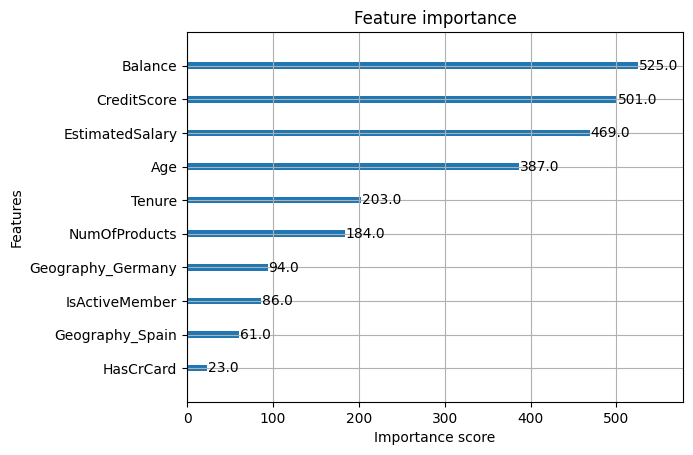

In [22]:
plot_importance(xgb_cv.best_estimator_);

Esto nos dice que las cuatro características más importantes utilizadas por nuestro modelo fueron `EstimatedSalary`, `Balance`, `CreditScore`, y `Age`. Esta es información muy útil. En un proyecto completo, volveríamos y examinaríamos estas características muy de cerca para entender cómo y por qué están afectando la rotación.

En este punto, también sería una buena idea volver y agregar las predicciones del modelo y la característica `Gender` a cada muestra en nuestros datos. Luego podríamos examinar qué tan uniformemente distribuye el modelo su error a través de las identidades de género reportadas.


<a name="trade-offs"></a>
## Un recordatorio sobre los compromisos en el modelado

Recuerda, la decisión de usar solo el modelo campeón para predecir en los datos de prueba viene con un compromiso. El beneficio es que obtenemos una idea real de cómo esperaríamos que el modelo se desempeñara en datos nuevos y no vistos. El costo de esta decisión es que, al usar las puntuaciones de validación para _ajustar_ los hiperparámetros _y_ seleccionar el modelo campeón, corremos el riesgo de seleccionar el modelo que más sobreajustó a los datos de validación.

Alternativamente, podríamos haber seleccionado nuestro modelo campeón usando todos nuestros modelos ajustados para predecir en los datos de prueba y eligiendo el que mejor hubiera funcionado. Eso también habría tenido un compromiso. No habría tanto riesgo de sobreajuste a los datos de validación, pero al usar los datos de prueba para seleccionar nuestro modelo campeón, no obtendríamos una idea verdaderamente objetiva de cómo el modelo se desempeñaría en datos nuevos y no vistos. Necesitaríamos un nuevo conjunto de datos para eso, lo que significa que habríamos tenido que reservar más datos desde el principio, resultando en menos datos para entrenar el modelo.

Con datos suficientes, un enfoque más riguroso sería:

1. Dividir los datos en conjuntos de entrenamiento, validación y prueba
2. Ajustar los hiperparámetros usando validación cruzada en el conjunto de entrenamiento
3. Usar _todos_ los modelos ajustados para predecir en el conjunto de validación
4. Seleccionar un modelo campeón basado en el rendimiento en el conjunto de validación
5. Usar solo el modelo campeón para predecir en los datos de prueba

Cada decisión de modelado viene con un compromiso. Lo más importante es que seas consciente de los compromisos y apliques el mejor razonamiento a la tarea en cuestión.


## Enfoque más riguroso:

<img src="./optimal_model_flow.svg"/>


**¡Felicidades!** Has completado este laboratorio. Sin embargo, es posible que no notes una marca de verificación verde junto a este elemento en la plataforma de Coursera. Por favor, continúa tu progreso independientemente de la marca de verificación. Solo haz clic en el icono de "guardar" en la parte superior de este cuaderno para asegurarte de que tu trabajo ha sido registrado.

Ahora entiendes cómo usar Python para construir e interpretar un modelo de clasificación XGBoost. En adelante, puedes comenzar a usar Python para construir e interpretar modelos de clasificación XGBoost con tus propios datos.


In [25]:
X.loc[5000]

CreditScore                834
Age                         68
Tenure                       9
Balance              130169.27
NumOfProducts                2
HasCrCard                    0
IsActiveMember               1
EstimatedSalary        93112.2
Geography_Germany         True
Geography_Spain          False
Name: 5000, dtype: object

In [ ]:
from xgboost import XGBClassifier
import pickle
import pandas as pd

In [ ]:
with open('xgb_cv_model_emi.pickle', 'rb') as to_read:
    xgb_cv = pickle.load(to_read)


In [30]:
X.loc[8477].values.reshape(1, -1)

array([[np.int64(556), np.int64(42), np.int64(0), np.float64(115915.53),
        np.int64(2), np.int64(0), np.int64(1), np.float64(125435.47),
        np.True_, np.False_]], dtype=object)

In [32]:
xgb_cv.predict(X.loc[8477].values.reshape(1, -1))

array([0])